In [1]:
import os, copy
import numpy as np
import jax
import jax.numpy as jnp
from jax import vmap
import matplotlib.pyplot as plt
import pandas as pd
import interpax
from scipy.interpolate import interp1d

from jax_cosmo import Cosmology
import jax_cosmo.background as bkgrd
from jax_cosmo.background import radial_comoving_distance

from godmax.get_Cls  import get_Cl
from godmax.get_covs import get_cov
from godmax.base_class import get_vmapped_func_warg
from godmax.base_class import base_class
from godmax.get_radial_profiles import Profiles
from godmax.get_Pkzs import get_Pkz

from tSZxEuclid.godmax.config.loader import merge_params
from tSZxEuclid.godmax.sampling.ell  import setup_ell_arrays

import diag_utils


import copy as _copy, time as _time
import arviz as az
import jax as _jax
import jax.numpy as _jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import NUTS, MCMC
from getdist import MCSamples
from getdist import plots as gd_plots
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import os

/home/vtinnane/micromamba/envs/tSZxEuclid-godmax/lib/python3.11/site-packages/jax_cosmo/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound
/home/vtinnane/micromamba/envs/tSZxEuclid-godmax/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from pathlib import Path

# ── Anchor: directory containing this notebook ───────────────────────────────
HERE = Path().resolve()          
DEVELOP = HERE.parents[2]        

# ── Parameter files (diagnostics/params/) ────────────────────────────────────
PARAM_DIR = HERE / 'params'
sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = merge_params(
    str(PARAM_DIR / 'params_default.yaml'),
    str(PARAM_DIR / 'params.yaml'),
)

halo_params_dict['lowpass_Pmm1h_lowk'] = True
halo_params_dict['kthresh_lowpass_Pmm1h_lowk'] = 0.01  # k in h/Mpc below which 1h is suppressed                          
analysis_dict['is_cmb_lensing'] = True          

# ── Cosmology (jax_cosmo) ────────────────────────────────────────────────────
cosmo_params = sim_params_dict['cosmo']
cosmo_jax = Cosmology(
    Omega_c  = cosmo_params['Om0'] - cosmo_params['Ob0'],
    Omega_b  = cosmo_params['Ob0'],
    h        = cosmo_params['H0'] / 100.,
    sigma8   = cosmo_params['sigma8'],
    n_s      = cosmo_params['ns'],
    Omega_k  = 0.,
    w0       = cosmo_params.get('w0', -1.0),
    wa       = 0.,
)

# ── ell array (mutates analysis_dict and halo_params_dict in place) ──────────
setup_ell_arrays(analysis_dict, halo_params_dict, lmin=80.0, lmax=1000.0, dl_log=0.1025851)
print(f"nell = {len(analysis_dict['l_array_survey'])}, "
      f"ell range [{float(analysis_dict['l_array_survey'][0]):.1f}, "
      f"{float(analysis_dict['l_array_survey'][-1]):.1f}]")

# ── Galaxy n(z) paths ────────────────────────────────────────────────────────
DNDZ_DIR = DEVELOP / 'tSZxEuclid' / 'Data' / 'dndz'

def to_comoving_nz(z_array, nz_array, cosmo):
    """Convert non-normalised n(z) [#gal/z] to comoving n(z) [(Mpc/h)^-3]."""
    a = 1.0 / (1.0 + z_array)
    chi = radial_comoving_distance(cosmo, a)
    dchi_dz = (2.998e5) / bkgrd.H(cosmo, a)   # c [km/s] / H(a) [km/s/(Mpc/h)]
    dV_dzdOmega = chi**2 * dchi_dz
    return nz_array / dV_dzdOmega

dndz_gal = np.loadtxt(DNDZ_DIR / 'nz_euclid_forecast_bin-all.txt')
z_gal  = dndz_gal[:, 0]
nz_gal = dndz_gal[:, 1]
nz_gal_comoving = to_comoving_nz(z_gal, nz_gal, cosmo_jax)
analysis_dict['nbar_gal_comoving_zarray'] = z_gal
analysis_dict['nbar_gal_comoving_val']    = nz_gal_comoving

# ── Lens N(z) bins ───────────────────────────────────────────────────────────
nbins_lens   = 5
nz_lens      = {}
nz_info_dict = {'nbins_lens': nbins_lens}

for nbin in range(nbins_lens):
    d = np.loadtxt(DNDZ_DIR / f'nz_norm_euclid_forecast_bin-{nbin+1}.txt')
    nz_lens[nbin]              = d[:, 1]
    nz_info_dict[f'nz{nbin}'] = nz_lens[nbin]
z_lens = d[:, 0]
nz_info_dict['z_array_lens'] = z_lens
analysis_dict['nz_lens_info_dict'] = nz_info_dict

# ── Source N(z) bins (same as lens for mock) ─────────────────────────────────
nbins_source = 5
nz_source  = {}
nz_info_src = {'nbins': nbins_source}

for nbin in range(nbins_source):
    d = np.loadtxt(DNDZ_DIR / f'nz_norm_euclid_forecast_bin-{nbin+1}.txt')
    nz_source[nbin]             = d[:, 1]
    nz_info_src[f'nz{nbin}']  = nz_source[nbin]
z_source = d[:, 0]
nz_info_src['z_array_source'] = z_source
analysis_dict['nz_source_info_dict'] = nz_info_src

# ── Per-bin nbar [gal/arcmin²] ───────────────────────────────────────────────
deg2_to_arcmin2 = 3600.0
nz_gal_interp   = interp1d(z_gal, nz_gal, bounds_error=False, fill_value=0.0)
nz_gal_on_zlens = nz_gal_interp(z_lens)

pz_bins = np.vstack([nz_lens[jb] for jb in range(nbins_lens)])   # (nbins, Nz)
pz_sum  = np.sum(pz_bins, axis=0)
nbar_lens_bins = np.zeros(nbins_lens)
for jb in range(nbins_lens):
    frac_j = np.zeros_like(z_lens)
    valid  = pz_sum > 0
    frac_j[valid] = pz_bins[jb, valid] / pz_sum[valid]
    nbar_lens_bins[jb] = np.trapezoid(nz_gal_on_zlens * frac_j, z_lens) / deg2_to_arcmin2
analysis_dict['nbar_lens_bins'] = nbar_lens_bins

# ── SO LAT noise ─────────────────────────────────────────────────────────────
SO_NOISE = DEVELOP / 'tSZxEuclid' / 'Data' / 'SO_LAT_Nell_T_atmv1_baseline_fsky0p4_ILC_tSZ.txt'
analysis_dict['yy_noise_ell_fname'] = str(SO_NOISE)

# ── Output directory for figures ─────────────────────────────────────────────
FIGDIR = HERE / 'mcmc_plots'
FIGDIR.mkdir(exist_ok=True)

print('nbar_lens_bins [gal/arcmin²]:', nbar_lens_bins)
print(f"Halo mass range: [{halo_params_dict['lg10_Mmin']}, {halo_params_dict['lg10_Mmax']}], nM={halo_params_dict['nM']}")
print(f"z grid: [{halo_params_dict['zmin']}, {halo_params_dict['zmax']}], nz={halo_params_dict['nz']}")
print(f"PARAM_DIR : {PARAM_DIR}")
print(f"DNDZ_DIR  : {DNDZ_DIR}")
print(f"FIGDIR    : {FIGDIR}")


ERROR:2026-04-23 15:21:27,867:jax._src.xla_bridge:475: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/vtinnane/micromamba/envs/tSZxEuclid-godmax/lib/python3.11/site-packages/jax/_src/xla_bridge.py", line 473, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/vtinnane/micromamba/envs/tSZxEuclid-godmax/lib/python3.11/site-packages/jax_plugins/xla_cuda12/__init__.py", line 328, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/vtinnane/micromamba/envs/tSZxEuclid-godmax/lib/python3.11/site-packages/jax_plugins/xla_cuda12/__init__.py", line 285, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: Unknown CUDA error 303; cuGetErrorName failed. This probably means that JAX was unable to

nell = 24, ell range [84.3, 892.6]
nbar_lens_bins [gal/arcmin²]: [0.91251697 0.8918078  0.8918939  0.93620033 1.58377251]
Halo mass range: [11.5, 15.5], nM=24
z grid: [0.01, 1.6], nz=22
PARAM_DIR : /home/vtinnane/Documents/Codes/develop/GODMAX/notebooks/diagnostics/params
DNDZ_DIR  : /home/vtinnane/Documents/Codes/develop/tSZxEuclid/Data/dndz
FIGDIR    : /home/vtinnane/Documents/Codes/develop/GODMAX/notebooks/diagnostics/mcmc_plots


In [3]:

base_test = base_class(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)
profiles_test = Profiles(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, base_class_obj=base_test)
Pkz_test = get_Pkz(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Profiles_obj=profiles_test)
Cls_test = get_Cl(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Pkz_obj=Pkz_test)
cov_test = get_cov(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Cls_test)

z_th = np.array(Cls_test.z_array)
nz = len(z_th)
z_sel = np.unique([0, nz//4, nz//2, 3*nz//4, nz-1])
ell_th = np.array(analysis_dict['l_array_survey'])

Loaded yy noise from file; Cl_y_y_tot_mat = theory + noise


In [4]:
# -----------------------------------------------------------------------------
# Basic arrays / kernels
# -----------------------------------------------------------------------------
ell_th   = np.asarray(Cls_test.ell_array)
efac     = ell_th * (ell_th + 1.0) / (2.0 * np.pi)

# -----------------------------------------------------------------------------
# Stored signal-only totals from class
# -----------------------------------------------------------------------------
def get_stored_dl(Cl_obj, key):
    if key == 'kk':
        return np.asarray(Cl_obj.Cl_kappa_kappa_tot_mat) * efac[:, None, None]
    elif key == 'ky':
        return np.asarray(Cl_obj.Cl_kappa_y_tot_mat) * efac[:, None]
    elif key == 'gg':
        return np.asarray(Cl_obj.Cl_gal_gal_tot_mat) * efac[:, None, None]
    elif key == 'gy':
        return np.asarray(Cl_obj.Cl_gal_y_tot_mat) * efac[:, None]
    elif key == 'gk':
        return np.asarray(Cl_obj.Cl_gal_kappa_tot_mat) * efac[:, None, None]
    elif key == 'yy':
        if hasattr(Cl_obj, "Cl_y_y_signal_mat"):
            return np.asarray(Cl_obj.Cl_y_y_signal_mat) * efac
        _noise_data = np.loadtxt(analysis_dict['yy_noise_ell_fname'])
        _yy_noise = np.interp(ell_th, _noise_data[:, 0], _noise_data[:, 1])
        return (np.asarray(Cl_obj.Cl_y_y_tot_mat) - _yy_noise) * efac
    else:
        raise ValueError(f"Unknown key: {key}")

In [5]:
import re
from pathlib import Path

def make_safe_filename(s):
    s = str(s)
    s = s.replace(" ", "_")
    s = s.replace("/", "_")
    s = s.replace(".", "p")
    s = re.sub(r"[^A-Za-z0-9_\-]+", "", s)
    return s

In [18]:
import copy
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable


def deep_copy_dicts(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict):
    return (
        copy.deepcopy(sim_params_dict),
        copy.deepcopy(halo_params_dict),
        copy.deepcopy(analysis_dict),
        copy.deepcopy(other_params_dict),
    )


def rebuild_pipeline(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict):
    base_obj = base_class(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)
    profiles_obj = Profiles(
        sim_params_dict, halo_params_dict, analysis_dict, other_params_dict,
        base_class_obj=base_obj
    )
    pkz_obj = get_Pkz(
        sim_params_dict, halo_params_dict, analysis_dict, other_params_dict,
        Profiles_obj=profiles_obj
    )
    cls_obj = get_Cl(
        sim_params_dict, halo_params_dict, analysis_dict, other_params_dict,
        Pkz_obj=pkz_obj
    )
    cov_obj = get_cov(
        sim_params_dict, halo_params_dict, analysis_dict, other_params_dict,
        cls_obj
    )
    return base_obj, profiles_obj, pkz_obj, cls_obj, cov_obj


def apply_nested_update(d, path, value):
    cur = d
    for k in path[:-1]:
        cur = cur[k]
    cur[path[-1]] = value


def get_target_dict(group, simd, halod, anad, othd):
    if group == 'sim':
        return simd
    elif group == 'halo':
        return halod
    elif group == 'analysis':
        return anad
    elif group == 'other':
        return othd
    else:
        raise ValueError("param_group must be one of 'sim', 'halo', 'analysis', 'other'")


def get_raw_cl(Cl_obj, analysis_dict, key):
    ell = np.asarray(Cl_obj.ell_array)
    if key == 'kk':
        arr = np.asarray(Cl_obj.Cl_kappa_kappa_tot_mat)
    elif key == 'ky':
        arr = np.asarray(Cl_obj.Cl_kappa_y_tot_mat)
    elif key == 'gk':
        arr = np.asarray(Cl_obj.Cl_gal_kappa_tot_mat)
    else:
        raise ValueError(f"Unknown key: {key}")
    return ell, arr


def extract_selected_cls_raw(Cls_obj, analysis_dict, probes=('gk', 'ky', 'kk')):
    out = {}
    ell = None
    for p in probes:
        ell, arr = get_raw_cl(Cls_obj, analysis_dict, p)
        out[p] = arr
    return ell, out


In [19]:
def run_param_sweep(param_path, param_group, values, probes=('gk', 'ky', 'kk'), verbose=True):
    """
    Rebuild the C_ell pipeline for each entry in `values`.

    param_path : tuple of keys into the target dict, e.g. ('cosmo', 'sigma8')
    param_group: 'sim', 'halo', 'analysis', or 'other'
    values     : 1-D iterable of parameter values to sweep

    Returns
    -------
    ell       : (nell,) array
    cls_sweep : dict  probe -> ndarray  shape (n_vals, nell, ...)
    """
    from tqdm import tqdm

    ell_ref    = None
    cls_sweep  = {p: [] for p in probes}
    param_name = '.'.join(str(k) for k in param_path)

    for jv, val in enumerate(tqdm(values, desc=param_name)):
        sim_v, halo_v, ana_v, oth_v = deep_copy_dicts(
            sim_params_dict, halo_params_dict, analysis_dict, other_params_dict
        )
        target = get_target_dict(param_group, sim_v, halo_v, ana_v, oth_v)
        apply_nested_update(target, param_path, float(val))

        _, _, _, cls_obj, _ = rebuild_pipeline(sim_v, halo_v, ana_v, oth_v)
        ell_now, cls_now = extract_selected_cls_raw(cls_obj, ana_v, probes=probes)

        if ell_ref is None:
            ell_ref = ell_now
        for p in probes:
            cls_sweep[p].append(cls_now[p])

    return ell_ref, {p: np.array(cls_sweep[p]) for p in probes}


In [20]:
def plot_param_sweep(
    ell, cls_sweep, param_values, param_label,
    probes=('gk', 'ky', 'kk'),
    cmap_name='coolwarm',
    save_path=None,
    figsize=(14, 4.5),
    lw=1.3,
    alpha=0.85,
):
    """
    3-panel sweep plot: one curve per parameter value, colored by that value.

    cls_sweep : dict probe -> ndarray (n_vals, nell, ...)
    For kk / gk (3-D): plots the auto-diagonal tomographic bins (i, i).
    For ky (2-D): plots all source bins.
    Single colorbar on the right shows the parameter range.
    """
    probe_titles = {
        'gk': r'$C_\ell^{g\kappa}$',
        'ky': r'$C_\ell^{\kappa y}$',
        'kk': r'$C_\ell^{\kappa\kappa}$',
    }

    cmap = cm.get_cmap(cmap_name)
    norm = Normalize(vmin=float(param_values[0]), vmax=float(param_values[-1]))

    fig, axes = plt.subplots(1, len(probes), figsize=figsize)
    if len(probes) == 1:
        axes = [axes]

    for ax, probe in zip(axes, probes):
        arr = cls_sweep[probe]           # (n_vals, nell, ...)

        for jv, val in enumerate(param_values):
            color = cmap(norm(float(val)))
            cl_v  = arr[jv]              # (nell, ...) for this parameter value

            if cl_v.ndim == 2:           # ky: (nell, n_source)
                for jb in range(cl_v.shape[1]):
                    ax.plot(ell, cl_v[:, jb], color=color, lw=lw, alpha=alpha)
            else:                        # kk / gk: (nell, n1, n2) — auto-diagonal
                n_bins = min(cl_v.shape[1], cl_v.shape[2])
                for jb in range(n_bins):
                    ax.plot(ell, cl_v[:, jb, jb], color=color, lw=lw, alpha=alpha)

        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_title(probe_titles.get(probe, probe), fontsize=14)
        ax.set_xlabel(r'$\ell$', fontsize=13)
        ax.grid(alpha=0.25)
        ax.tick_params(labelsize=12)

    axes[0].set_ylabel(r'$C_\ell$', fontsize=13)

    # single colorbar to the right of all panels — no space stealing from individual axes
    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, shrink=0.85, aspect=20, pad=0.02)
    cbar.set_label(param_label, fontsize=14, rotation=270, labelpad=20)
    cbar.ax.tick_params(labelsize=12)

    fig.suptitle(param_label, fontsize=15, y=1.02)

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=200, bbox_inches='tight')
        print(f"Saved: {save_path}")

    plt.show()
    return fig, axes


In [21]:
def sweep_and_plot(param_path, param_group, values, param_label,
                   fig_prefix='wl_sweep', cmap_name='coolwarm'):
    """Run a parameter sweep and plot it.  Returns (ell, cls_sweep, values)."""
    ell, cls_sweep = run_param_sweep(param_path, param_group, values)
    fname = make_safe_filename(param_label)
    save_path = FIGDIR / f"{fig_prefix}_{fname}.png"
    plot_param_sweep(
        ell, cls_sweep, values, param_label,
        cmap_name=cmap_name, save_path=save_path,
    )
    return ell, cls_sweep, values


cosmo.sigma8:   0%|          | 0/10 [00:00<?, ?it/s]

Loaded yy noise from file; Cl_y_y_tot_mat = theory + noise


cosmo.sigma8:  10%|█         | 1/10 [00:42<06:20, 42.23s/it]

Loaded yy noise from file; Cl_y_y_tot_mat = theory + noise


cosmo.sigma8:  20%|██        | 2/10 [01:23<05:32, 41.59s/it]

...

Loaded yy noise from file; Cl_y_y_tot_mat = theory + noise


cosmo.sigma8:  90%|█████████ | 9/10 [06:03<00:40, 40.14s/it]

Loaded yy noise from file; Cl_y_y_tot_mat = theory + noise


cosmo.sigma8: 100%|██████████| 10/10 [06:44<00:00, 40.47s/it]
/tmp/ipykernel_297754/3701569173.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


Saved: /home/vtinnane/Documents/Codes/develop/GODMAX/notebooks/diagnostics/mcmc_plots/wl_sweep_sigma_8.png


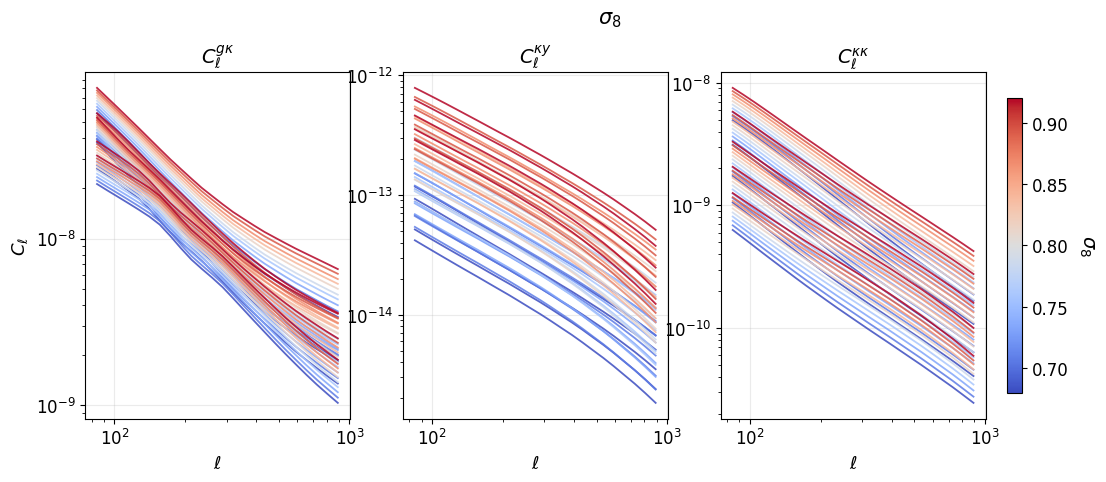

In [22]:
# 1. σ8 — amplitude of matter fluctuations
#    Fiducial 0.8; sweep ±15% to bracket current S8 tension range
sigma8_values = np.linspace(0.68, 0.92, 10)
ell_s8, cls_s8, _ = sweep_and_plot(
    ('cosmo', 'sigma8'), 'sim', sigma8_values,
    param_label=r'$\sigma_8$',
)


cosmo.Om0:   0%|          | 0/10 [00:00<?, ?it/s]

Loaded yy noise from file; Cl_y_y_tot_mat = theory + noise


cosmo.Om0:  10%|█         | 1/10 [00:39<05:53, 39.29s/it]

Loaded yy noise from file; Cl_y_y_tot_mat = theory + noise


cosmo.Om0:  20%|██        | 2/10 [01:20<05:25, 40.69s/it]

...

Loaded yy noise from file; Cl_y_y_tot_mat = theory + noise


cosmo.Om0:  90%|█████████ | 9/10 [06:05<00:40, 40.85s/it]

Loaded yy noise from file; Cl_y_y_tot_mat = theory + noise


cosmo.Om0: 100%|██████████| 10/10 [06:47<00:00, 40.75s/it]
/tmp/ipykernel_297754/3701569173.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


Saved: /home/vtinnane/Documents/Codes/develop/GODMAX/notebooks/diagnostics/mcmc_plots/wl_sweep_Omega_m.png


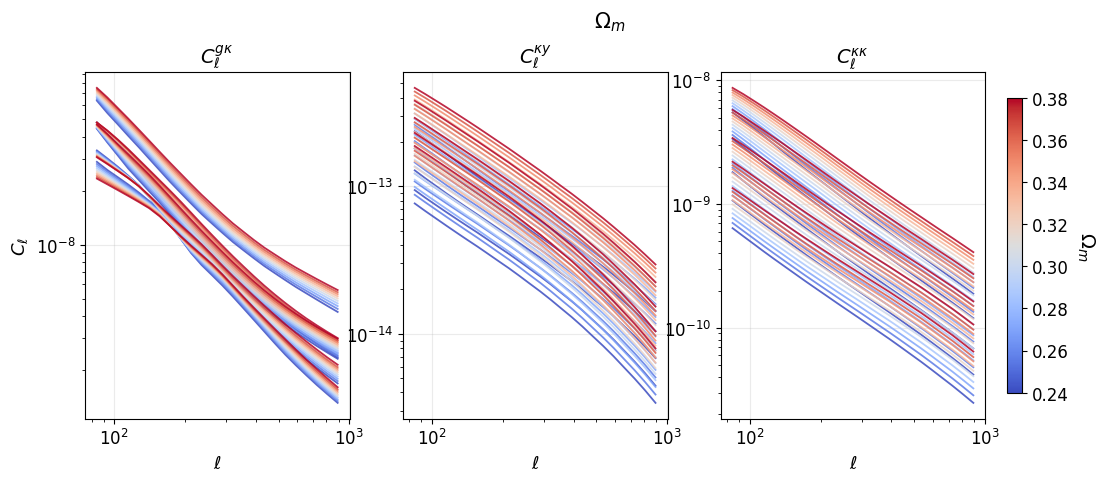

In [23]:
# 2. Ωm — total matter density
#    Fiducial 0.3; sweep a range consistent with current CMB + BAO posteriors
Om0_values = np.linspace(0.24, 0.38, 10)
ell_Om, cls_Om, _ = sweep_and_plot(
    ('cosmo', 'Om0'), 'sim', Om0_values,
    param_label=r'$\Omega_m$',
)


cosmo.H0:   0%|          | 0/10 [00:00<?, ?it/s]

Loaded yy noise from file; Cl_y_y_tot_mat = theory + noise


cosmo.H0:  10%|█         | 1/10 [00:43<06:33, 43.70s/it]

Loaded yy noise from file; Cl_y_y_tot_mat = theory + noise


cosmo.H0:  20%|██        | 2/10 [01:28<05:53, 44.23s/it]

...

Loaded yy noise from file; Cl_y_y_tot_mat = theory + noise


cosmo.H0:  90%|█████████ | 9/10 [06:28<00:43, 43.22s/it]

Loaded yy noise from file; Cl_y_y_tot_mat = theory + noise


cosmo.H0: 100%|██████████| 10/10 [07:12<00:00, 43.20s/it]
/tmp/ipykernel_297754/3701569173.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


Saved: /home/vtinnane/Documents/Codes/develop/GODMAX/notebooks/diagnostics/mcmc_plots/wl_sweep_H_0__km_s_Mpc.png


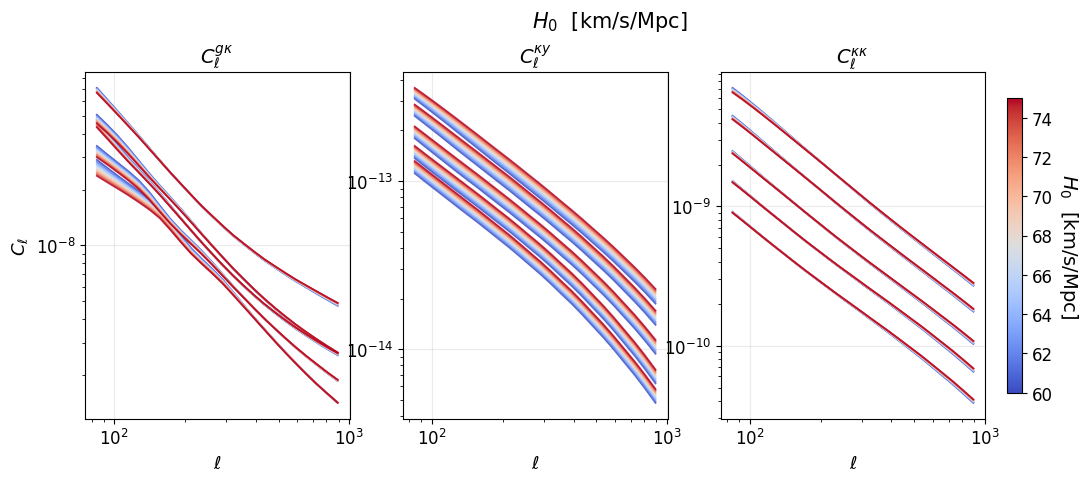

In [24]:
# 3. H0 — Hubble constant (comoving distances, P(k) normalisation)
#    Sweeps 60–75 km/s/Mpc, covering both Planck and SH0ES anchors
H0_values = np.linspace(60.0, 75.0, 10)
ell_H0, cls_H0, _ = sweep_and_plot(
    ('cosmo', 'H0'), 'sim', H0_values,
    param_label=r'$H_0$  [km/s/Mpc]',
)


cosmo.ns:   0%|          | 0/10 [00:00<?, ?it/s]

Loaded yy noise from file; Cl_y_y_tot_mat = theory + noise


cosmo.ns:  10%|█         | 1/10 [00:40<06:02, 40.29s/it]

Loaded yy noise from file; Cl_y_y_tot_mat = theory + noise


cosmo.ns:  20%|██        | 2/10 [01:23<05:34, 41.83s/it]

...

Loaded yy noise from file; Cl_y_y_tot_mat = theory + noise


cosmo.ns:  90%|█████████ | 9/10 [06:19<00:42, 42.01s/it]

Loaded yy noise from file; Cl_y_y_tot_mat = theory + noise


cosmo.ns: 100%|██████████| 10/10 [07:04<00:00, 42.48s/it]
/tmp/ipykernel_297754/3701569173.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


Saved: /home/vtinnane/Documents/Codes/develop/GODMAX/notebooks/diagnostics/mcmc_plots/wl_sweep_n_s.png


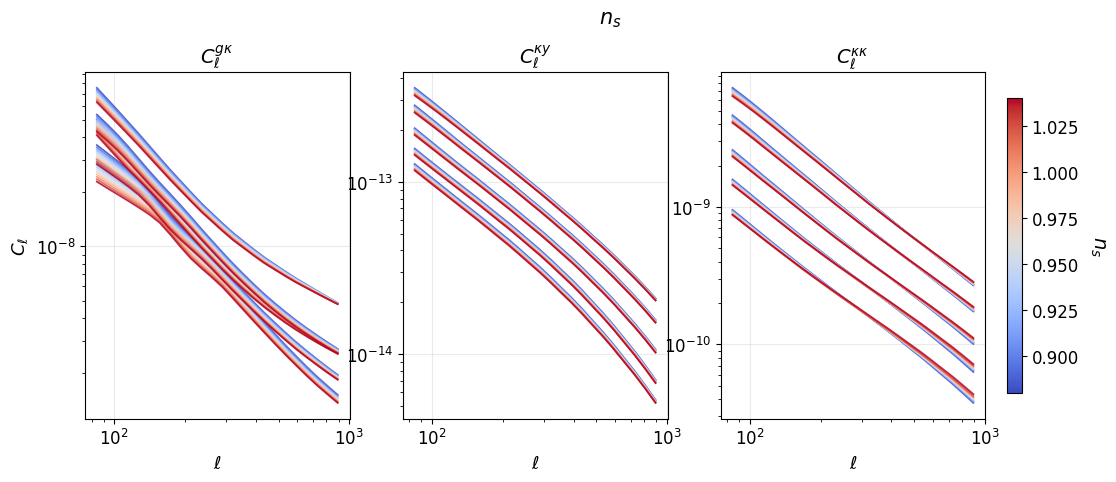

In [25]:
# 4. ns — spectral index (tilts P(k); response grows with ell)
#    Fiducial 0.96; sweep ±8% covers CMB posterior width generously
ns_values = np.linspace(0.88, 1.04, 10)
ell_ns, cls_ns, _ = sweep_and_plot(
    ('cosmo', 'ns'), 'sim', ns_values,
    param_label=r'$n_s$',
)


cosmo.w0:   0%|          | 0/10 [00:00<?, ?it/s]

Loaded yy noise from file; Cl_y_y_tot_mat = theory + noise


cosmo.w0:  10%|█         | 1/10 [00:38<05:49, 38.89s/it]

Loaded yy noise from file; Cl_y_y_tot_mat = theory + noise


cosmo.w0:  20%|██        | 2/10 [01:19<05:20, 40.08s/it]

...

Loaded yy noise from file; Cl_y_y_tot_mat = theory + noise


cosmo.w0:  90%|█████████ | 9/10 [06:21<00:43, 43.18s/it]

Loaded yy noise from file; Cl_y_y_tot_mat = theory + noise


cosmo.w0: 100%|██████████| 10/10 [07:06<00:00, 42.68s/it]
/tmp/ipykernel_297754/3701569173.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


Saved: /home/vtinnane/Documents/Codes/develop/GODMAX/notebooks/diagnostics/mcmc_plots/wl_sweep_w_0.png


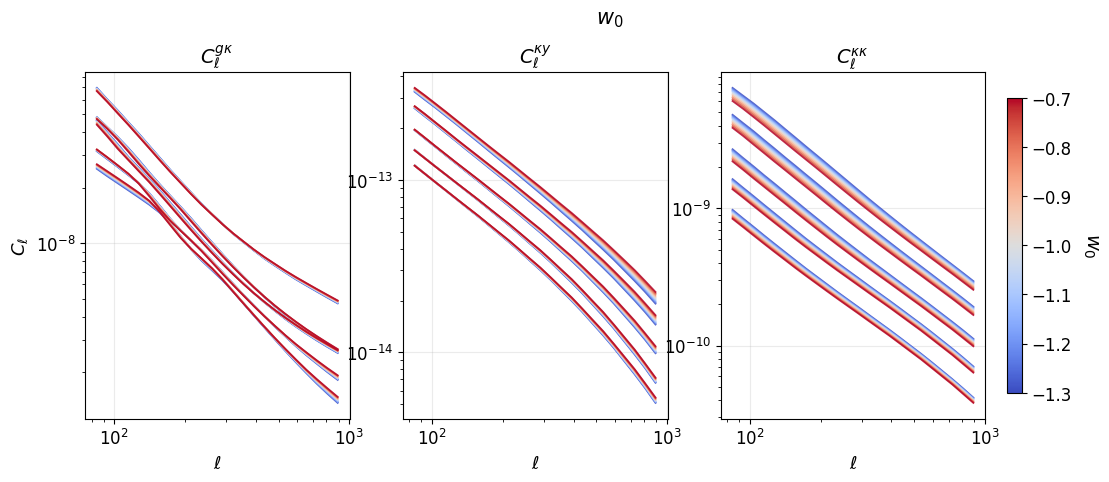

In [26]:
# 5. w0 — dark energy equation of state
#    Fiducial −1.0 (ΛCDM); −1.3 to −0.7 is the observationally interesting range
w0_values = np.linspace(-1.3, -0.7, 10)
ell_w0, cls_w0, _ = sweep_and_plot(
    ('cosmo', 'w0'), 'sim', w0_values,
    param_label=r'$w_0$',
)


A_IA:   0%|          | 0/10 [00:00<?, ?it/s]

Loaded yy noise from file; Cl_y_y_tot_mat = theory + noise


A_IA:  10%|█         | 1/10 [00:43<06:35, 44.00s/it]

Loaded yy noise from file; Cl_y_y_tot_mat = theory + noise


A_IA:  20%|██        | 2/10 [01:28<05:52, 44.01s/it]

...

Loaded yy noise from file; Cl_y_y_tot_mat = theory + noise


A_IA:  90%|█████████ | 9/10 [06:31<00:42, 42.86s/it]

Loaded yy noise from file; Cl_y_y_tot_mat = theory + noise


A_IA: 100%|██████████| 10/10 [07:13<00:00, 43.38s/it]
/tmp/ipykernel_297754/3701569173.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


Saved: /home/vtinnane/Documents/Codes/develop/GODMAX/notebooks/diagnostics/mcmc_plots/wl_sweep_A_rm_IA.png


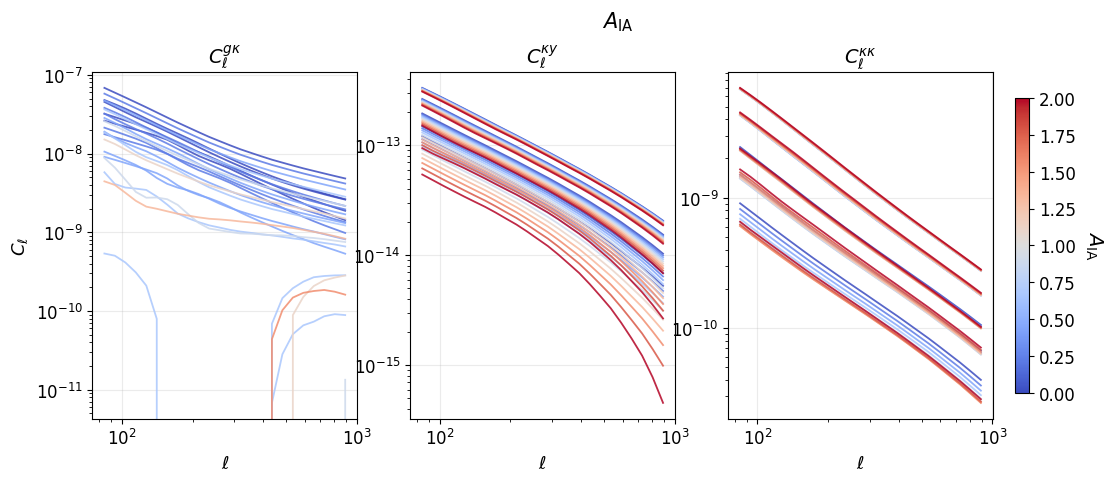

In [27]:
# 6. A_IA — intrinsic alignment amplitude (key WL systematic)
#    A_IA=0 is perfect alignment removal; A_IA~1-2 is typical DES/KiDS posterior
AIA_values = np.linspace(0.0, 2.0, 10)
ell_AIA, cls_AIA, _ = sweep_and_plot(
    ('A_IA',), 'other', AIA_values,
    param_label=r'$A_{\rm IA}$',
)


Saved summary to: /home/vtinnane/Documents/Codes/develop/GODMAX/notebooks/diagnostics/mcmc_plots/wl_sweep_sensitivity_summary.png


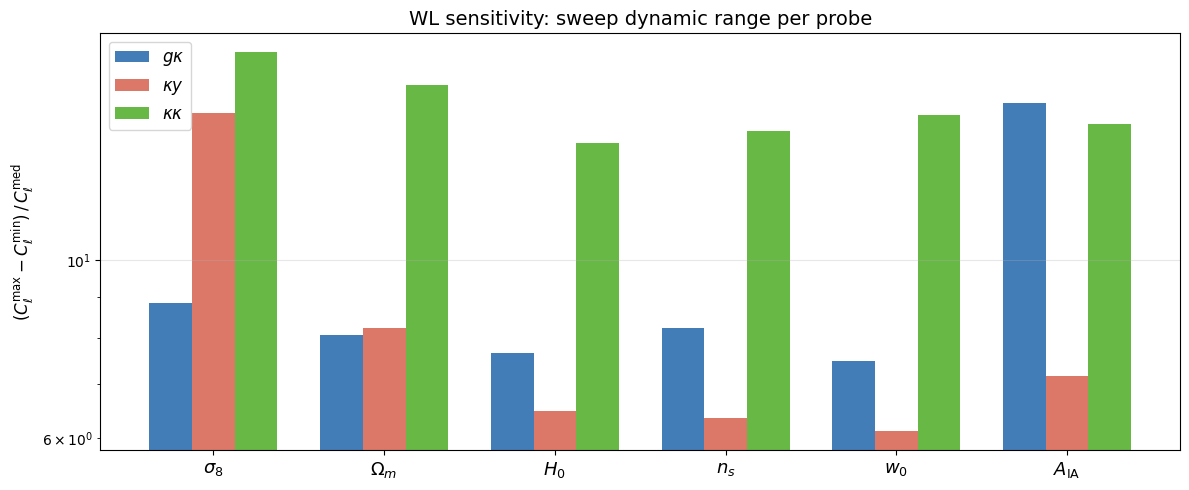

In [28]:
# =============================================================================
# Summary: total sweep range as fraction of median C_ell
# bar = (max − min) / median  across the sweep, auto-diagonal bins for 3D probes
# =============================================================================

def _sweep_dynamic_range(cls_sweep, probe):
    """
    (max - min) / median across the parameter sweep.
    ky  (ndim=3: n_vals, nell, n_src): use all source bins.
    kk/gk (ndim=4: n_vals, nell, n1, n2): use auto-diagonal bins (i,i).
    """
    arr = cls_sweep[probe]
    if arr.ndim == 3:
        # ky: (n_vals, nell, n_source)
        slab = arr
    else:
        # kk / gk: (n_vals, nell, n1, n2) — take diagonal
        n_bins = min(arr.shape[2], arr.shape[3])
        slab = np.stack([arr[:, :, jb, jb] for jb in range(n_bins)], axis=2)
    pos = slab[slab > 0]
    if pos.size == 0:
        return np.nan
    return float((np.nanmax(slab) - np.nanmin(pos)) / np.nanmedian(pos))


all_sweeps = {
    r'$\sigma_8$':   (cls_s8,  sigma8_values),
    r'$\Omega_m$':   (cls_Om,  Om0_values),
    r'$H_0$':        (cls_H0,  H0_values),
    r'$n_s$':        (cls_ns,  ns_values),
    r'$w_0$':        (cls_w0,  w0_values),
    r'$A_{\rm IA}$': (cls_AIA, AIA_values),
}
probes_summary = ['gk', 'ky', 'kk']
probe_labels   = {'gk': r'$g\kappa$', 'ky': r'$\kappa y$', 'kk': r'$\kappa\kappa$'}

param_names = list(all_sweeps.keys())
x = np.arange(len(param_names))
width = 0.25
colors = {'gk': '#2166ac', 'ky': '#d6604d', 'kk': '#4dac26'}

fig, ax = plt.subplots(figsize=(12, 5))
for k, probe in enumerate(probes_summary):
    vals = [_sweep_dynamic_range(cls, probe) for cls, _ in all_sweeps.values()]
    ax.bar(x + k * width, vals, width, label=probe_labels[probe],
           color=colors[probe], alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(param_names, fontsize=13)
ax.set_ylabel(r'$(C_\ell^{\rm max} - C_\ell^{\rm min})\,/\,C_\ell^{\rm med}$', fontsize=12)
ax.set_title('WL sensitivity: sweep dynamic range per probe', fontsize=14)
ax.legend(fontsize=12)
ax.set_yscale('log')
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()

save_path = FIGDIR / 'wl_sweep_sensitivity_summary.png'
fig.savefig(save_path, dpi=200, bbox_inches='tight')
print(f"Saved summary to: {save_path}")
plt.show()
